In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print('All imports OK')

All imports OK


In [ ]:
df = pd.read_csv('water_potability.csv')
print('Shape:', df.shape)
print()
print('Missing values:')
print(df.isnull().sum())
print()
print('Target distribution:')
print(df['Potability'].value_counts())
df.head()

Shape: (3276, 10)

Missing values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Target distribution:
Potability
0    1998
1    1278
Name: count, dtype: int64


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


## 2. EDA

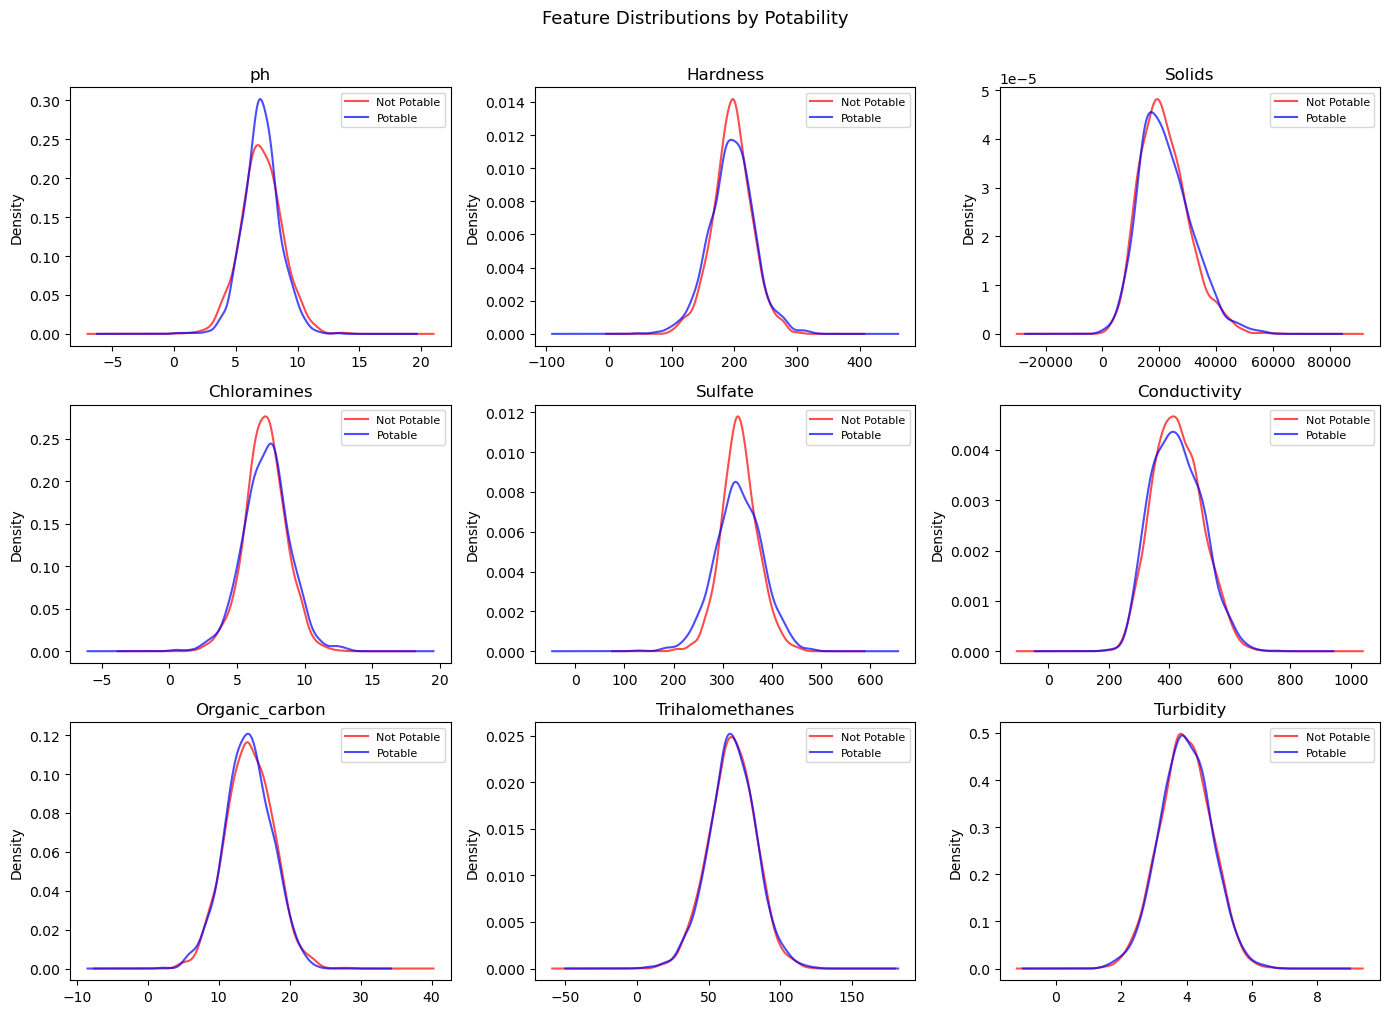

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
features = df.columns.drop('Potability')
for ax, col in zip(axes.flatten(), features):
    df[df['Potability']==0][col].dropna().plot(kind='kde', ax=ax, label='Not Potable', color='red', alpha=0.7)
    df[df['Potability']==1][col].dropna().plot(kind='kde', ax=ax, label='Potable',     color='blue', alpha=0.7)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Potability', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

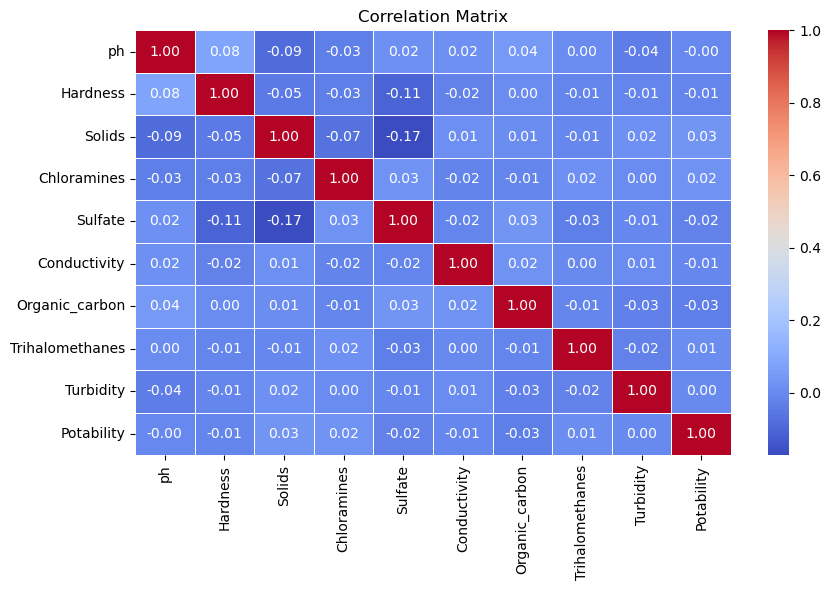

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [ ]:

for col in ['ph', 'Sulfate', 'Trihalomethanes']:
    medians = df.groupby('Potability')[col].median()
    for cls in [0, 1]:
        mask = df['Potability'].eq(cls) & df[col].isna()
        df.loc[mask, col] = medians[cls]

print('Missing after imputation:', df.isnull().sum().sum())

Missing after imputation: 0


In [ ]:
X = df.drop('Potability', axis=1)
y = df['Potability']

# Stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale after split to prevent data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns)

# SMOTE on training set only
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'Train: {X_train_res.shape[0]} samples after SMOTE')
print(f'Test:  {X_test_scaled.shape[0]} samples')
print('Class balance after SMOTE:', pd.Series(y_train_res).value_counts().to_dict())

Train: 3196 samples after SMOTE
Test:  656 samples
Class balance after SMOTE: {0: 1598, 1: 1598}


## 4. Train XGBoost (Best Hyperparameters)

In [ ]:
# Best params from GridSearchCV (CV ROC-AUC: 0.9029)
model = XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    n_jobs=-1
)

model.fit(X_train_res, y_train_res)
print('Model trained.')

Model trained.


## 5. Evaluate

In [ ]:
y_pred  = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

print('=== XGBoost — Test Set Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_probs):.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Not Potable', 'Potable']))

=== XGBoost — Test Set Results ===
Accuracy:  0.7881
Precision: 0.7312
Recall:    0.7227
F1 Score:  0.7269
ROC-AUC:   0.8757

=== Classification Report ===
              precision    recall  f1-score   support

 Not Potable       0.82      0.83      0.83       400
     Potable       0.73      0.72      0.73       256

    accuracy                           0.79       656
   macro avg       0.78      0.78      0.78       656
weighted avg       0.79      0.79      0.79       656



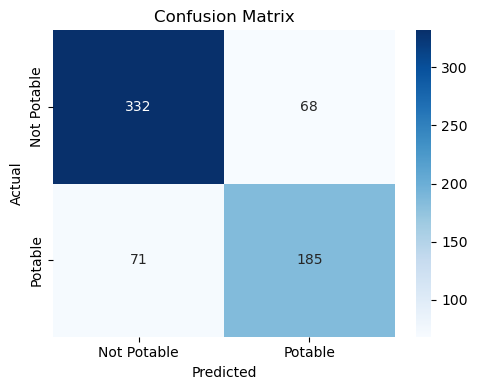

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Potable', 'Potable'],
            yticklabels=['Not Potable', 'Potable'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

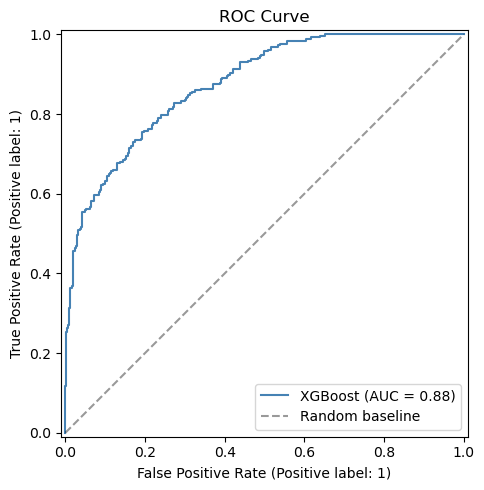

In [ ]:
# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test, ax=ax, name='XGBoost', color='steelblue')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Random baseline')
ax.set_title('ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Threshold Tuning

Optimal threshold: 0.31  (F1 = 0.7348)


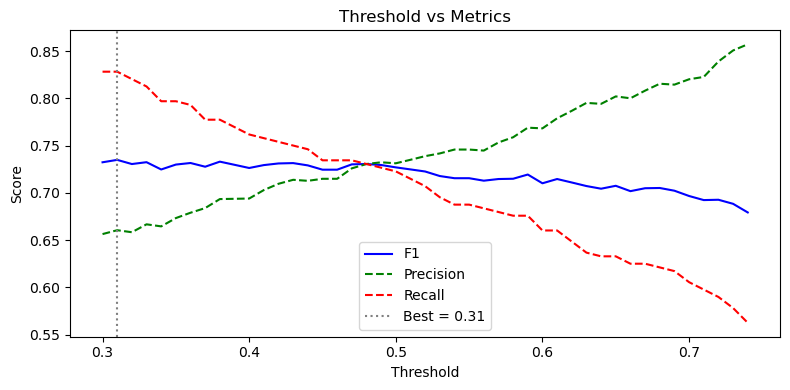

In [ ]:
thresholds = np.arange(0.30, 0.75, 0.01)
f1_scores, prec_scores, rec_scores = [], [], []

for t in thresholds:
    preds = (y_probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    prec_scores.append(precision_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))

best_t = thresholds[np.argmax(f1_scores)]
print(f'Optimal threshold: {best_t:.2f}  (F1 = {max(f1_scores):.4f})')

plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores,   label='F1',       color='blue')
plt.plot(thresholds, prec_scores, label='Precision', color='green', linestyle='--')
plt.plot(thresholds, rec_scores,  label='Recall',    color='red',   linestyle='--')
plt.axvline(best_t, color='gray', linestyle=':', label=f'Best = {best_t:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold vs Metrics')
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Final result at optimal threshold
y_final = (y_probs >= best_t).astype(int)
print(f'=== Final Results at threshold = {best_t:.2f} ===')
print(classification_report(y_final, y_test, target_names=['Not Potable', 'Potable']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_probs):.4f}')

=== Final Results at threshold = 0.31 ===
              precision    recall  f1-score   support

 Not Potable       0.73      0.87      0.79       335
     Potable       0.83      0.66      0.73       321

    accuracy                           0.77       656
   macro avg       0.78      0.76      0.76       656
weighted avg       0.78      0.77      0.76       656

ROC-AUC: 0.8757


## 7. Feature Importance

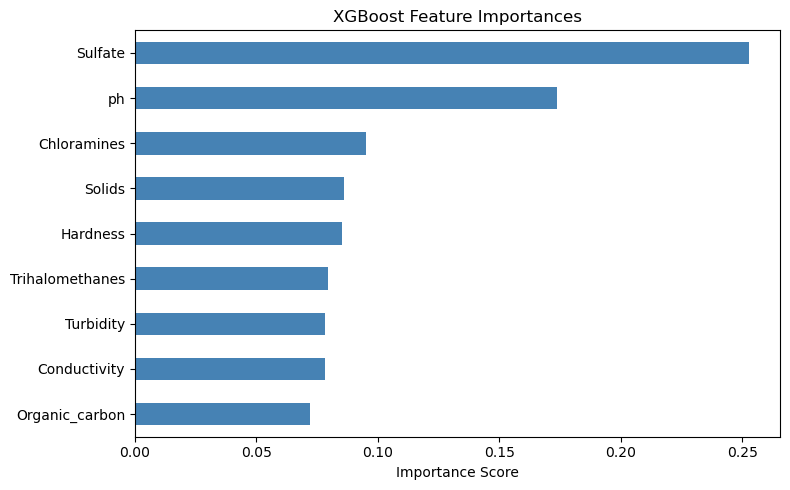

Top 3 most important features:
Sulfate        0.252795
ph             0.173465
Chloramines    0.094941
dtype: float32


In [ ]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importances')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 3 most important features:')
print(feat_imp.sort_values(ascending=False).head(3))

In [ ]:
import joblib
joblib.dump({
    'model':     model,
    'scaler':    scaler,
    'threshold': best_t,
    'features':  list(X.columns),
    'roc_auc':   round(roc_auc_score(y_test, y_probs), 4)
}, 'water_potability_xgb.pkl')
print('Saved: water_potability_xgb.pkl')

Saved: water_potability_xgb.pkl
